## Fig5


In [18]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm


from scipy.stats import linregress

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable

import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature



from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

In [3]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-15,25))
ocean_mask = masks.open_ocean.isin([1,2,3]) # mask for tropical indo-pacifi
#ocean_mask = masks.seamask # all tropical oceans

In [4]:
composite_years = [1982, 1987, 1991, 1997,  2015, 2009]


### W500

In [5]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(25, -15)).sortby('lat')

In [6]:

w500 = w500.where(ocean_mask)
#w500 = w500.interp(lat = tp.lat, lon = tp.lon, method = 'nearest')


w500_amjjas = w500.where((w500.time.dt.month<=9)& (w500.time.dt.month>=4)).groupby('time.year').mean('time')
w2023_amjjas = w500_amjjas.sel(year = 2023)
wcomposite_amjjas = w500_amjjas.where(w500_amjjas.year.isin(composite_years), drop = True).mean('year')

w500_aso = w500.where(w500.time.dt.month.isin([8,9,10])).groupby('time.year').mean('time')
w2023_aso = w500_aso.sel(year = 2023)
wcomposite_aso = w500_aso.where(w500_aso.year.isin(composite_years), drop = True).mean('year')

In [7]:
w500_aso = w500.where((w500.time.dt.month<=10)& (w500.time.dt.month>=8)).groupby('time.year').mean('time')
w2023_aso = w500_aso.sel(year = 2023)
wcomposite_aso = w500_aso.where(w500_aso.year.isin(composite_years), drop = True).mean('year')

w500_aso = w500.where(w500.time.dt.month.isin([8,10,10])).groupby('time.year').mean('time')
w2023_aso = w500_aso.sel(year = 2023)
wcomposite_aso = w500_aso.where(w500_aso.year.isin(composite_years), drop = True).mean('year')

### SST


In [8]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15)).sortby('lat').where(ocean_mask)-273.15
#sst = sst.interp(lat = tp.lat, lon = tp.lon, method = 'nearest')


#yearly average Jan-Sept
sst_y = sst.where((sst.time.dt.month<=9) & (sst.time.dt.month>=4)).groupby('time.year').mean()

#change in sst_y
d_sst = sst_y - sst_y.roll(year = 1)
d_2023 = d_sst.sel(year = 2023)
d_composite = d_sst.where(d_sst.year.isin(composite_years), drop = True).mean('year')

In [9]:
sst_aso = sst.where(sst.time.dt.month.isin([8,9,10]), drop= True).groupby('time.year').mean()
sst2023_aso = sst_aso.sel(year = 2023)
sstcomposite_aso = sst_aso.where(sst_aso.year.isin(composite_years), drop= True).mean('year')

### TP

In [10]:
fp = '/data/jmex/NOAA/latest/temp/precip.mon.mean.nc'
tp = xr.open_dataset(fp).sel(lat = slice(-15,25), time = slice(None,None))
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})
tp = tp.where(tp.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [11]:
tp_clim = tp.sel(year = slice(1991, 2020)).mean('year')
tp = tp - tp_clim

#interpolate on sst grid
tp = tp.interp(lat = sst.lat, lon = sst.lon, method = 'linear')

tp_2023 = tp.sel(year = 2023)
tp_composite = tp.where(tp.year.isin(composite_years), drop = True).mean('year')

In [12]:
fp = '/data/jmex/NOAA/latest/temp/precip.mon.mean.nc'
tp = xr.open_dataset(fp).sel(lat = slice(-15,25), time = slice(None,None))
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})
tp = tp.where(tp.time.dt.month.isin([4,5,6,7,8,9])).groupby('time.year').mean()

In [13]:
tp_clim = tp.sel(year = slice(1991, 2020)).mean('year')
tp = tp - tp_clim

#interpolate on sst grid
tp = tp.interp(lat = sst.lat, lon = sst.lon, method = 'linear')

tp_2023_amjjas = tp.sel(year = 2023)
tp_composite_amjjas = tp.where(tp.year.isin(composite_years), drop = True).mean('year')

In [21]:
# save the data
fig5 = xr.Dataset(
    {
        "d_composite": d_composite["sst"],
        "d_2023": d_2023["sst"],
        "sstcomposite_aso": sstcomposite_aso["sst"],
        "sst2023_aso": sst2023_aso["sst"],
        "wcomposite_amjjas": wcomposite_amjjas["w"],
        "w2023_amjjas": w2023_amjjas["w"],
        "tp_composite": tp_composite["tp"],
        "tp_2023": tp_2023["tp"],
    }
)

fig5.to_netcdf("preprocessed_data/fig5.nc")

## Plotting

In [19]:
fp = '/home/jmex/Python_Notebooks/sea_mask.nc'
m = xr.open_dataset(fp).sel(lat = slice(-15, 25))


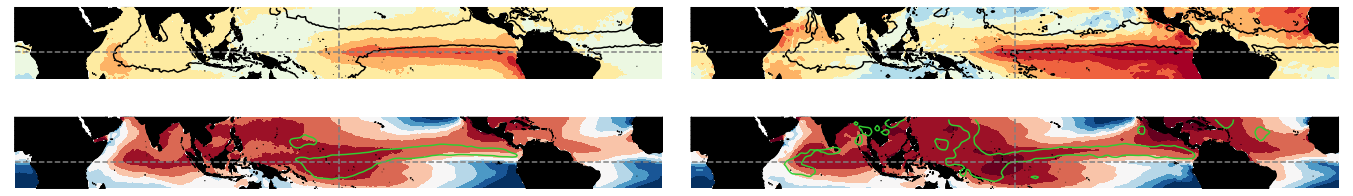

In [20]:

# --- 0. Set up professional plotting parameters ---
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
    'lines.linewidth': 1.5,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.7,
    'savefig.dpi': 300,
    'savefig.format': 'svg',
})

lon, lat = d_composite.lon, d_composite.lat
aspect = (lat.max() - lat.min()) / (lon.max() - lon.min())

levels_d = np.linspace(-2, 2, 9)

# --- Create Figure and Gridspec ---
fig = plt.figure(figsize=(24, 4))
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.02, hspace=0.02)  # Tight control over spacing

# Define projection
projection = ccrs.PlateCarree(central_longitude=180)

# Create axes manually
ax0 = fig.add_subplot(gs[0, 0], projection=projection)
ax1 = fig.add_subplot(gs[0, 1], projection=projection)
ax2 = fig.add_subplot(gs[1, 0], projection=projection)
ax3 = fig.add_subplot(gs[1, 1], projection=projection)

# --- Panel (a) ---
cf0 = ax0.contourf(lon, lat, d_composite.sst, levels=levels_d, cmap='RdYlBu_r', extend='both', transform=ccrs.PlateCarree())
c = ax0.contour(lon, lat, wcomposite_amjjas.w, levels=[0], colors='k', linewidths=1.5, transform=ccrs.PlateCarree())
#ax0.clabel(c, fontsize=10, fmt='0 hPa/s')

# --- Panel (b) ---
cf1 = ax1.contourf(lon, lat, d_2023.sst, levels=levels_d, cmap='RdYlBu_r', extend='both', transform=ccrs.PlateCarree())
c = ax1.contour(lon, lat, w2023_amjjas.w, levels=[0], colors='k', linewidths=1.5, transform=ccrs.PlateCarree())
#ax1.clabel(c, fontsize=10, fmt='0 hPa/s')

# --- Panel (c) ---
levels_sst = np.linspace(23, 30, 8)
cf2 = ax2.contourf(lon, lat, sstcomposite_aso.sst, levels=levels_sst, cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
c = ax2.contour(lon, lat, tp_composite.tp, levels=[2], colors='limegreen', linewidths=1.5, transform=ccrs.PlateCarree())
#ax2.clabel(c, fontsize=10, fmt='2 mm/day')

# --- Panel (d) ---
cf3 = ax3.contourf(lon, lat, sst2023_aso.sst, levels=levels_sst, cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
c = ax3.contour(lon, lat, tp_2023.tp, levels=[2], colors='limegreen', linewidths=1.5, transform=ccrs.PlateCarree())
#ax3.clabel(c, fontsize=10, fmt='2 mm/day')

# --- Common settings ---
for ax in [ax0, ax1, ax2, ax3]:
    m.sea_mask.plot(ax=ax, cmap='binary_r', zorder=0, add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title('')
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    ax.set_extent([lon.min(), lon.max(), -15, 25], crs=ccrs.PlateCarree())
    ax.set_box_aspect(aspect)

    # Add land and coastlines
    ax.add_feature(cfeature.LAND, facecolor='k', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=1)

    # Plot vertical line at 180° longitude
    ax.plot([180, 180], [lat.min(), lat.max()], linestyle='--', color='grey', transform=ccrs.PlateCarree())

    # Plot horizontal line at 0° latitude
    ax.plot([lon.min(), lon.max()], [0, 0], linestyle='--', color='grey', transform=ccrs.PlateCarree())

    # Clean ticks and spines
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[:].set_visible(False)

plt.show()


/tmp/ipykernel_4133266/3148688033.py:1: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  c = plt.colorbar(cf3, orientation = 'horizontal')
/tmp/ipykernel_4133266/3148688033.py:6: MatplotlibDeprecationWarning: Starting from Matplotlib 3.6, colorbar() will steal space from the mappable's axes, rather than from the current axes, to place the colorbar.  To silence this warning, explicitly pass the 'ax' argument to colorbar().
  c = plt.colorbar(cf1, orientation = 'horizontal')


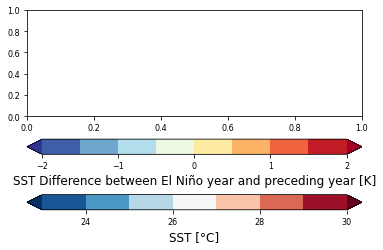

In [22]:
c = plt.colorbar(cf3, orientation = 'horizontal')
c.set_label(label = 'SST [°C]',fontweight = 'book', fontsize = 12)
c.set_ticks([24, 26, 28, 30])


c = plt.colorbar(cf1, orientation = 'horizontal')
c.set_label(label = 'SST Difference between El Niño year and preceding year [K]', fontweight = 'regular', fontsize = 12)
c.set_ticks([-2, -1, 0, 1, 2])
plt.savefig('output/Fig5cbar.pdf')